# Summarize DLS data (Prometheus Panta) across SEC fractions and MV, per cell line, for visual representation in Prism / Python

**Experiment layout**

- Cell lines: `WT`, `CD63`, `CD9`
- Per cell line: 13 SEC fractions (`F1`-`F13`) + 1 microvesicle fraction (`MV`)
- Per fraction/MV: 3 replicate subfolders
- Per replicate: 10 acquisition subfolders (1-10), each with its own intensity-distribution Excel file (`Radius [nm]`, `Relative frequency [%]`, `S.D.`)

So the folder depth is: `RAW_DATA_DIR / "<CellLine> <Fraction>_0_Phosphate-buffered Saline" / <replicate> / <acquisition> / *.xlsx`

**Assumptions made below (please adjust if wrong):**
1. `RAW_DATA_DIR` is the single root folder that directly contains the `"WT F8_0_..."` style folders.
2. Replicate and acquisition subfolder names don't need to follow a strict pattern - we just take every subdirectory at each level, the same way the original script did.
3. For the per-column labels in the exported Excel file, we try to grab the trailing number from each replicate/acquisition folder name (e.g. "Replicate 1" -> `R1`, "Acquisition 3" -> `A3`). If a folder name has no trailing number, we just fall back to its full name.
4. `MV` is plotted/sorted **first**, followed by `F1...F13` in numeric order.

In [1]:
# 1. Locate every fraction/MV folder for each cell line, then every replicate and acquisition inside it
from pathlib import Path
import re
import pandas as pd

RAW_DATA_DIR =Path(r"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, CD9\RAW_DATA_DIR\RAW_DATA_DIR")  # <-- update this to the folder that directly contains the "WT F8_0_..." style folders

CELL_LINES = ["WT", "CD63", "CD9"]

# Matches folder names like "WT F8_0_Phosphate-buffered Saline" or "CD63 MV_0_Phosphate-buffered Saline"
FOLDER_PATTERN = re.compile(r"^(WT|CD63|CD9)\s+(F\d+|MV)_")

records = []

for fraction_folder in [p for p in RAW_DATA_DIR.iterdir() if p.is_dir()]:

    match = FOLDER_PATTERN.match(fraction_folder.name)

    if not match:
        print(f"Skipping folder (name doesn't match expected pattern): {fraction_folder.name}")
        continue

    cell_line, fraction = match.groups()

    for replicate in [p for p in fraction_folder.iterdir() if p.is_dir()]:

        for acquisition in [p for p in replicate.iterdir() if p.is_dir()]:

            records.append({
                "cell_line": cell_line,
                "fraction": fraction,
                "fraction_folder": fraction_folder.name,
                "replicate": replicate.name,
                "acquisition": acquisition.name,
                "path": acquisition,
            })

df = pd.DataFrame(records)
df


,cell_line,fraction,fraction_folder,replicate,acquisition,path
0,CD9,F5,CD9 F5_0_Phosphate-buffered Saline,Replicate 1,Acquisition 1,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."
1,CD9,F5,CD9 F5_0_Phosphate-buffered Saline,Replicate 1,Acquisition 10,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."
2,CD9,F5,CD9 F5_0_Phosphate-buffered Saline,Replicate 1,Acquisition 2,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."
3,CD9,F5,CD9 F5_0_Phosphate-buffered Saline,Replicate 1,Acquisition 3,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."
4,CD9,F5,CD9 F5_0_Phosphate-buffered Saline,Replicate 1,Acquisition 4,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."
...,...,...,...,...,...,...
1535,CD9,F2,CD9 F2_0_Phosphate-buffered Saline,Replicate 6,Acquisition 5,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."
1536,CD9,F2,CD9 F2_0_Phosphate-buffered Saline,Replicate 6,Acquisition 6,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."
1537,CD9,F2,CD9 F2_0_Phosphate-buffered Saline,Replicate 6,Acquisition 7,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."
1538,CD9,F2,CD9 F2_0_Phosphate-buffered Saline,Replicate 6,Acquisition 8,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ..."


In [2]:
# 2. Give fractions a sortable rank: MV first, then F1 .. F13 in numeric order
def fraction_rank(fraction):
    if fraction == "MV":
        return 0
    return int(fraction[1:])

df["fraction_rank"] = df["fraction"].apply(fraction_rank)

df = df.sort_values(["cell_line", "fraction_rank", "replicate", "acquisition"]).reset_index(drop=True)

print("Cell lines found:", sorted(df["cell_line"].unique()))
print("Fractions found (MV first):", sorted(df["fraction"].unique(), key=fraction_rank))
df


Cell lines found: ['CD63', 'CD9', 'WT']
Fractions found (MV first): ['MV', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13']


,cell_line,fraction,fraction_folder,replicate,acquisition,path,fraction_rank
0,CD63,MV,CD63 MV_0_Phosphate-buffered Saline,Replicate 1,Acquisition 1,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",0
1,CD63,MV,CD63 MV_0_Phosphate-buffered Saline,Replicate 1,Acquisition 10,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",0
2,CD63,MV,CD63 MV_0_Phosphate-buffered Saline,Replicate 1,Acquisition 2,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",0
3,CD63,MV,CD63 MV_0_Phosphate-buffered Saline,Replicate 1,Acquisition 3,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",0
4,CD63,MV,CD63 MV_0_Phosphate-buffered Saline,Replicate 1,Acquisition 4,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",0
...,...,...,...,...,...,...,...
1535,WT,F13,WT F13_0_Phosphate-buffered Saline,Replicate 3,Acquisition 5,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",13
1536,WT,F13,WT F13_0_Phosphate-buffered Saline,Replicate 3,Acquisition 6,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",13
1537,WT,F13,WT F13_0_Phosphate-buffered Saline,Replicate 3,Acquisition 7,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",13
1538,WT,F13,WT F13_0_Phosphate-buffered Saline,Replicate 3,Acquisition 8,"E:\DLS\15_06_2026 Analysis F1-13 MV WT, CD63, ...",13


In [3]:
# 3. Load the intensity-distribution Excel file from each acquisition folder
#    Failsafe: if an acquisition is missing its Excel file, or the file is empty/unreadable/duplicated,
#    that single acquisition is skipped (logged below) instead of stopping the whole run.
from tqdm import tqdm

def load_measurement(folder_path):

    folder_path = Path(folder_path)

    # Skip Excel's temporary lock files (start with "~$") and the autocorrelation-function
    # export (filename ends in "acf.xlsx") - we only want the intensity distribution file.
    excel_files = [
        f for f in folder_path.glob("*.xlsx")
        if not f.name.startswith("~$") and not f.stem.lower().endswith("acf")
    ]

    valid_tables = []

    for file in excel_files:

        data = pd.read_excel(file)

        if data.empty:
            continue

        valid_tables.append(data)

    if len(valid_tables) == 0:
        raise ValueError(f"No valid Excel file found in {folder_path}")

    if len(valid_tables) > 1:
        raise ValueError(f"Multiple valid Excel files found in {folder_path}")

    return valid_tables[0]


def load_measurement_safe(folder_path):
    try:
        return load_measurement(folder_path), None
    except Exception as e:
        return None, str(e)


tqdm.pandas()

results = df["path"].progress_apply(load_measurement_safe)

df["data"] = results.apply(lambda r: r[0])
df["load_error"] = results.apply(lambda r: r[1])

failed = df[df["data"].isna()]

if len(failed) > 0:
    print(f"WARNING: {len(failed)} acquisition(s) could not be loaded and will be skipped:")
    for _, row in failed.iterrows():
        print(f"  - {row['cell_line']} {row['fraction']} / {row['replicate']} / {row['acquisition']}: {row['load_error']}")
else:
    print("All acquisitions loaded successfully.")

# Drop the failed rows so downstream pooling/plotting only sees valid data
df = df[df["data"].notna()].reset_index(drop=True)


100%|██████████| 1540/1540 [00:13<00:00, 114.06it/s]

All acquisitions loaded successfully.


In [4]:
# 4. Pool all replicate/acquisition curves belonging to the same cell line + fraction
#    into one wide table (one column per replicate/acquisition), using informative column names.

def trailing_number(name):
    # e.g. "Replicate 1" -> "1", "Acquisition 3" -> "3"; falls back to the full name if no trailing number
    match = re.search(r"(\d+)\s*$", name)
    return match.group(1) if match else name

pooled_tables = {}  # keys: (cell_line, fraction)

for (cell_line, fraction), group in df.groupby(["cell_line", "fraction"]):

    pooled = pd.DataFrame()
    pooled["Radius [nm]"] = group["data"].iloc[0]["Radius [nm]"]

    for _, row in group.iterrows():

        column_name = f"R{trailing_number(row['replicate'])}_A{trailing_number(row['acquisition'])}"

        pooled[column_name] = row["data"]["Relative frequency [%]"].values

    pooled_tables[(cell_line, fraction)] = pooled

list(pooled_tables.keys())[:5]


[('CD63', 'F1'),
 ('CD63', 'F10'),
 ('CD63', 'F11'),
 ('CD63', 'F12'),
 ('CD63', 'F13')]

In [5]:
# 5. Export pooled data to one Excel workbook per cell line, one sheet per fraction (MV first)
#    Each sheet has one column per replicate/acquisition -> ready for Prism to compute mean +/- SEM.

for cell_line in sorted(df["cell_line"].unique()):

    output_file = f"DLS_Fraction_Data_{cell_line}.xlsx"

    fractions_for_line = sorted(
        {frac for (cl, frac) in pooled_tables if cl == cell_line},
        key=fraction_rank
    )

    with pd.ExcelWriter(output_file) as writer:

        for fraction in fractions_for_line:

            pooled_tables[(cell_line, fraction)].to_excel(
                writer, sheet_name=fraction, index=False
            )

    print(f"Saved: {output_file}")


Saved: DLS_Fraction_Data_CD63.xlsx
Saved: DLS_Fraction_Data_CD9.xlsx
Saved: DLS_Fraction_Data_WT.xlsx


In [6]:
# 6. Build one mean-intensity-distribution curve per cell line + fraction
#    (averaged across all replicates/acquisitions) for the overview plot below.

mean_tables = {}  # keys: cell_line -> DataFrame with Radius [nm] + one column per fraction (MV first)

for cell_line in sorted(df["cell_line"].unique()):

    fractions_for_line = sorted(
        {frac for (cl, frac) in pooled_tables if cl == cell_line},
        key=fraction_rank
    )

    table = pd.DataFrame()
    table["Radius [nm]"] = pooled_tables[(cell_line, fractions_for_line[0])]["Radius [nm]"]

    for fraction in fractions_for_line:

        pooled = pooled_tables[(cell_line, fraction)]
        curve_cols = [c for c in pooled.columns if c != "Radius [nm]"]
        table[fraction] = pooled[curve_cols].mean(axis=1)

    mean_tables[cell_line] = table

mean_tables["WT"].head()


,Radius [nm],MV,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13
0,0.533670,0.001112,0.004747,0.011846,0.000034,0.001904,0.0,0.000000,0.000000,0.000000,0.000000,0.012980,0.0,0.0,0.000000
1,0.613591,0.001018,0.002412,0.016321,0.000381,0.001985,0.0,0.000000,0.000000,0.000169,0.000027,0.016643,0.0,0.0,0.000000
2,0.705480,0.001173,0.000604,0.021066,0.001341,0.001840,0.0,0.000293,0.000144,0.001784,0.000993,0.020122,0.0,0.0,0.000000
3,0.811131,0.001728,0.000000,0.022750,0.002426,0.001905,0.0,0.002965,0.001950,0.005630,0.002905,0.022954,0.0,0.0,0.001566
4,0.932603,0.002454,0.000620,0.019296,0.003248,0.002343,0.0,0.008330,0.004720,0.009766,0.007391,0.027377,0.0,0.0,0.004382


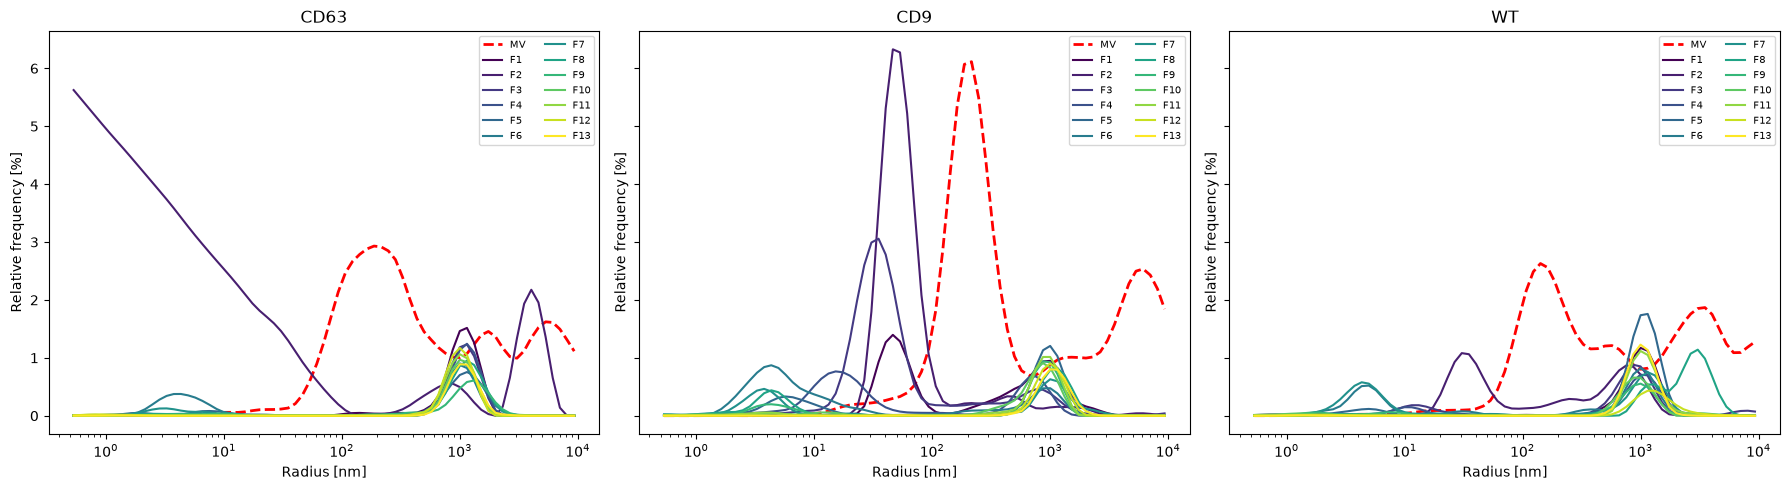

In [7]:
# 7. Plot the mean intensity distribution across fractions, one panel per cell line (MV first, then F1..F13)
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(1, len(mean_tables), figsize=(6 * len(mean_tables), 5), sharey=True)

if len(mean_tables) == 1:
    axes = [axes]

for ax, cell_line in zip(axes, sorted(mean_tables.keys())):

    table = mean_tables[cell_line]

    fraction_cols = sorted([c for c in table.columns if c != "Radius [nm]"], key=fraction_rank)
    sec_fractions = [f for f in fraction_cols if f != "MV"]

    colors = cm.viridis([i / max(len(sec_fractions) - 1, 1) for i in range(len(sec_fractions))])

    if "MV" in fraction_cols:
        ax.plot(table["Radius [nm]"], table["MV"], label="MV", color="red", linewidth=2, linestyle="--")

    for i, fraction in enumerate(sec_fractions):
        ax.plot(table["Radius [nm]"], table[fraction], label=fraction, color=colors[i])

    ax.set_xscale("log")
    ax.set_xlabel("Radius [nm]")
    ax.set_ylabel("Relative frequency [%]")
    ax.set_title(cell_line)
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


## Stacked-curve export for Prism

Prism doesn't have a built-in way to auto-stack XY curves - the usual trick is to add a fixed vertical
offset to each fraction's curve so they line up like a waterfall/stack instead of overlapping.
`OFFSET_STEP` below controls the gap between curves - increase it if curves still overlap, decrease it
if they're spread too far apart. `MV` sits at the bottom (offset 0), then `F1...F13` stack upward.

In [8]:
# 8. Build an offset ("stacked") version of each cell line's mean curves, for a clean stacked plot in Prism
#
# Fractions can have very different total signal/peak heights (e.g. MV vs. a dilute SEC fraction).
# If we just add a fixed offset to the raw values, low-signal fractions get visually flattened
# next to tall ones. NORMALIZE_BEFORE_STACKING fixes this by scaling every curve to the same peak
# height (100) first, so you're comparing the *shape/position* of each distribution, not its
# absolute amplitude. Turn it off if you specifically want to preserve relative signal intensity
# between fractions.

NORMALIZE_BEFORE_STACKING = True
OFFSET_STEP = 120 if NORMALIZE_BEFORE_STACKING else 20  # <-- tune this: vertical gap between consecutive curves

stacked_tables = {}

for cell_line, table in mean_tables.items():

    stacked = pd.DataFrame()
    stacked["Radius [nm]"] = table["Radius [nm]"]

    fraction_cols = sorted([c for c in table.columns if c != "Radius [nm]"], key=fraction_rank)

    for i, fraction in enumerate(fraction_cols):

        curve = table[fraction]

        if NORMALIZE_BEFORE_STACKING:
            peak = curve.max()
            curve = (curve / peak * 100) if peak > 0 else curve

        stacked[fraction] = curve + i * OFFSET_STEP

    stacked_tables[cell_line] = stacked

output_file = "DLS_Fraction_Data_Stacked_ForPrism.xlsx"

with pd.ExcelWriter(output_file) as writer:
    for cell_line, table in stacked_tables.items():
        table.to_excel(writer, sheet_name=cell_line, index=False)

print(f"Saved: {output_file}")
stacked_tables["WT"].head()


Saved: DLS_Fraction_Data_Stacked_ForPrism.xlsx


,Radius [nm],MV,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13
0,0.533670,0.042319,120.405290,241.095672,360.003864,480.268459,600.0,720.000000,840.000000,960.000000,1080.000000,1201.971016,1320.0,1440.0,1560.000000
1,0.613591,0.038736,120.205948,241.509578,360.043356,480.279856,600.0,720.000000,840.000000,960.014831,1080.004837,1202.527188,1320.0,1440.0,1560.000000
2,0.705480,0.044638,120.051590,241.948538,360.152414,480.259425,600.0,720.035612,840.019144,960.156340,1080.179003,1203.055408,1320.0,1440.0,1560.000000
3,0.811131,0.065750,120.000000,242.104282,360.275830,480.268529,600.0,720.360929,840.259291,960.493531,1080.523923,1203.485518,1320.0,1440.0,1560.127582
4,0.932603,0.093373,120.052925,241.784800,360.369194,480.330308,600.0,721.013885,840.627695,960.856087,1081.332942,1204.157074,1320.0,1440.0,1560.357017
